# Model Practice Worksheet

Dataset: California housing

Goal: predict whether a district has **high** or **low** median house value.

For each model, edit the hyperparameter options, run the validation test, and inspect the results.

After each validation test, manually enter the parameter you want to use for the final model. At the end, the notebook retrains the final models on train + validation and reports test accuracy for all three models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42

## Load Data

The CSV has one row per California district.

Features include median income, house age, average rooms, population, latitude, and longitude.

The target column is `high_value`, which tells us whether median house value is above or below the dataset median.

In [2]:
url = "https://raw.githubusercontent.com/jimmyrouse/BSR/main/california_housing_classification.csv"

df = pd.read_csv(url)

X = df.drop(columns=["MedHouseVal", "high_value"])
y = df["high_value"]

print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print("Target classes: 0 = lower value, 1 = higher value")
print("Median house value cutoff:", round(df["MedHouseVal"].median(), 3))

X.head()

Samples: 20640
Features: 8
Target classes: 0 = lower value, 1 = higher value
Median house value cutoff: 1.797


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Split Data

We use train, validation, and test sets.

- Train: fit models
- Validation: choose parameters
- Test: final check

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

pd.Series({
    "train": len(y_train),
    "validation": len(y_val),
    "test": len(y_test),
}).to_frame("n_samples")

,n_samples
train,14448
validation,3096
test,3096


## Practice 1: SVM

This SVM uses a **linear kernel**, so it learns a straight boundary. Edit `svm_C_values`, then run the validation test.

Questions:

1. Which `C` had the highest validation accuracy?
2. Did larger `C` always improve validation accuracy?
3. How different are training and validation accuracy?

In [4]:
# TODO: Change these values and rerun the SVM cells. Note: You can add C values if you want to test them
svm_C_values = [0.01, 0.1, 1, 10, 100]

In [5]:
svm_results = []

for C in svm_C_values:
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C, random_state=RANDOM_STATE),
    )
    model.fit(X_train, y_train)

    svm_results.append({
        "model": "SVM",
        "C": C,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "validation_accuracy": accuracy_score(y_val, model.predict(X_val)),
    })

svm_results = pd.DataFrame(svm_results).sort_values(
    ["validation_accuracy", "train_accuracy"],
    ascending=False,
).reset_index(drop=True)

svm_results

,model,C,train_accuracy,validation_accuracy
0,SVM,10.00,0.837140,0.839147
1,SVM,100.00,0.837140,0.839147
2,SVM,1.00,0.837348,0.838501
3,SVM,0.10,0.832434,0.833010
4,SVM,0.01,0.817414,0.811370


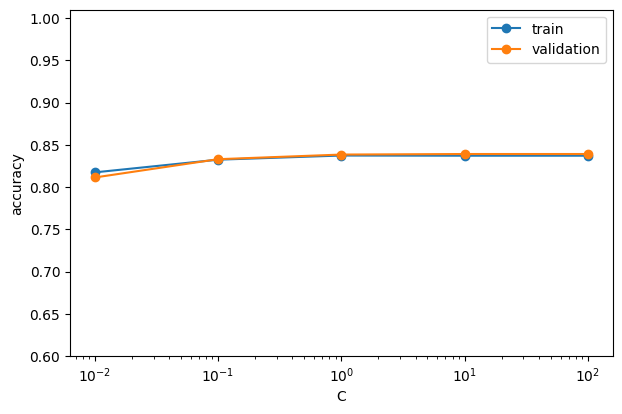

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

plot_df = svm_results.sort_values("C")
ax.plot(plot_df["C"], plot_df["train_accuracy"], marker="o", label="train")
ax.plot(plot_df["C"], plot_df["validation_accuracy"], marker="o", label="validation")
ax.set_xscale("log")
ax.set_xlabel("C")
ax.set_ylabel("accuracy")
ax.set_ylim(0.60, 1.01)
ax.legend()
plt.show()

## Choose SVM Parameter

Look at the SVM validation results above, then enter the `C` value you want to use for the final SVM.

In [7]:
# TODO: Choose the final SVM C value. Note: this is not the best C value. This should be changed
final_svm_C = 0.01

## Practice 2: Decision Tree

Edit `tree_depths`, then run the validation test.

Questions:

1. Which depth had the highest validation accuracy?
2. What happens to training accuracy as depth increases?
3. Do you see signs of overfitting?

In [8]:
# TODO: Change these values and rerun the decision tree cells.
tree_depths = [2, 4, 6, 8, 10, None]

In [9]:
tree_results = []

for depth in tree_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    tree_results.append({
        "model": "Decision Tree",
        "max_depth": "None" if depth is None else depth,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "validation_accuracy": accuracy_score(y_val, model.predict(X_val)),
    })

tree_results = pd.DataFrame(tree_results)
tree_results

,model,max_depth,train_accuracy,validation_accuracy
0,Decision Tree,2,0.740795,0.732235
1,Decision Tree,4,0.789936,0.781008
2,Decision Tree,6,0.834579,0.820090
3,Decision Tree,8,0.882406,0.846253
4,Decision Tree,10,0.917082,0.855297
5,Decision Tree,None,1.000000,0.840116


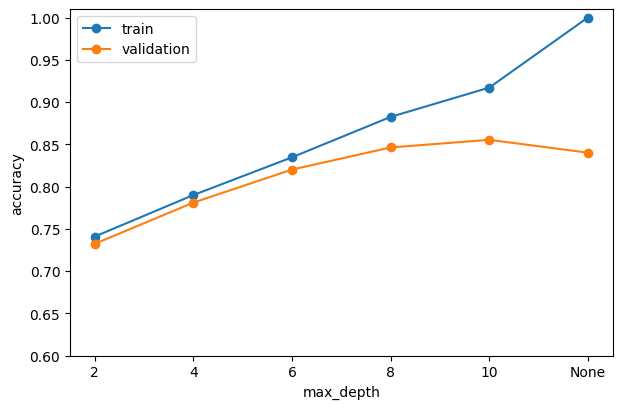

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(tree_results["max_depth"].astype(str), tree_results["train_accuracy"], marker="o", label="train")
ax.plot(tree_results["max_depth"].astype(str), tree_results["validation_accuracy"], marker="o", label="validation")
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_ylim(0.60, 1.01)
ax.legend()
plt.show()

## Choose Decision Tree Parameter

Look at the decision tree validation results above, then enter the `max_depth` you want to use for the final decision tree.

In [11]:
# TODO: Choose the final decision tree depth. Note: This is not the best choice, please change
final_tree_depth = 2

## Visualize One Tree

Change `chosen_tree_depth`, then rerun this cell.

A smaller depth is easier to read. A larger depth may fit the data better but becomes harder to interpret.

## Practice 3: Random Forest

Edit `n_estimators_values` and `forest_depth_values`, then run the validation test.

Questions:

1. Did adding more trees improve validation accuracy?
2. Which random forest settings worked best?
3. Was the random forest more stable than one decision tree?

In [12]:
# TODO: Change these values and rerun the random forest cells.
n_estimators_values = [10, 50, 100, 200]
forest_depth_values = [4, 8, 12, None]

In [13]:
forest_results = []

for n_estimators in n_estimators_values:
    for depth in forest_depth_values:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=depth,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)

        forest_results.append({
            "model": "Random Forest",
            "n_estimators": n_estimators,
            "max_depth": "None" if depth is None else depth,
            "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
            "validation_accuracy": accuracy_score(y_val, model.predict(X_val)),
        })

forest_results = pd.DataFrame(forest_results).sort_values(
    ["validation_accuracy", "train_accuracy"],
    ascending=False,
).reset_index(drop=True)

forest_results

,model,n_estimators,max_depth,train_accuracy,validation_accuracy
0,Random Forest,100,None,1.000000,0.897610
1,Random Forest,200,None,1.000000,0.897287
2,Random Forest,50,None,0.999723,0.896318
3,Random Forest,200,12,0.956188,0.887274
4,Random Forest,100,12,0.954873,0.884690
5,Random Forest,50,12,0.954734,0.883398
6,Random Forest,10,None,0.993286,0.882752
7,Random Forest,200,8,0.895626,0.871447
8,Random Forest,10,12,0.945321,0.869832
9,Random Forest,100,8,0.892165,0.867248


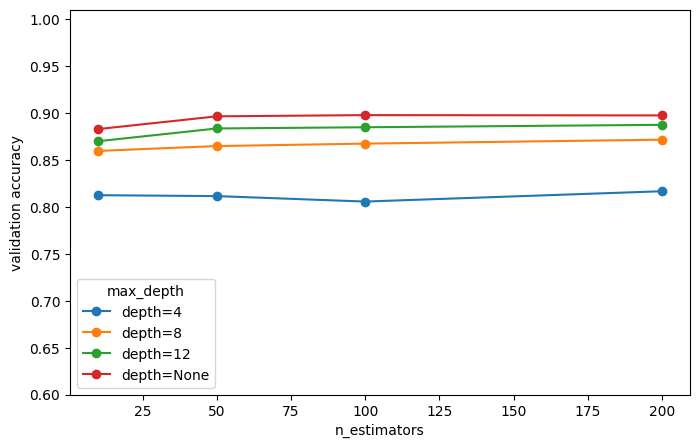

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

for depth, group in forest_results.groupby("max_depth"):
    group = group.sort_values("n_estimators")
    ax.plot(group["n_estimators"], group["validation_accuracy"], marker="o", label=f"depth={depth}")

ax.set_xlabel("n_estimators")
ax.set_ylabel("validation accuracy")
ax.set_ylim(0.60, 1.01)
ax.legend(title="max_depth")
plt.show()

## Choose Random Forest Parameters

Look at the random forest validation results above, then enter the values you want to use for the final random forest.

In [15]:
# TODO: Choose final random forest parameters. Note: These are not the best parameters, please change
final_forest_n_estimators = 50
final_forest_depth = 8

## Final Model Comparison

The next cell uses the parameters you entered above.

Each final model is retrained on `train + validation` and evaluated once on the test set.

In [16]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

final_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=final_svm_C, random_state=RANDOM_STATE),
)
final_svm.fit(X_train_val, y_train_val)

final_tree = DecisionTreeClassifier(max_depth=final_tree_depth, random_state=RANDOM_STATE)
final_tree.fit(X_train_val, y_train_val)

final_forest = RandomForestClassifier(
    n_estimators=final_forest_n_estimators,
    max_depth=final_forest_depth,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_forest.fit(X_train_val, y_train_val)

final_scores = pd.DataFrame({
    "model": ["SVM", "Decision Tree", "Random Forest"],
    "chosen_parameters": [
        f"C={final_svm_C}",
        f"max_depth={final_tree_depth}",
        f"n_estimators={final_forest_n_estimators}, max_depth={final_forest_depth}",
    ],
    "test_accuracy": [
        accuracy_score(y_test, final_svm.predict(X_test)),
        accuracy_score(y_test, final_tree.predict(X_test)),
        accuracy_score(y_test, final_forest.predict(X_test)),
    ],
})

final_scores

,model,chosen_parameters,test_accuracy
0,SVM,C=0.01,0.831718
1,Decision Tree,max_depth=2,0.740956
2,Random Forest,"n_estimators=50, max_depth=8",0.876615


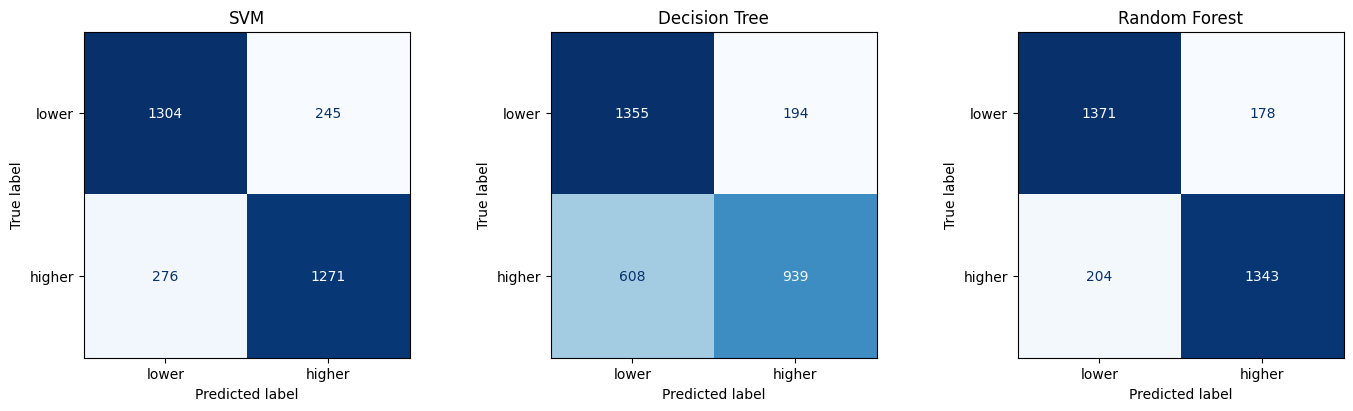

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

models = [final_svm, final_tree, final_forest]
titles = ["SVM", "Decision Tree", "Random Forest"]

for model, title, ax in zip(models, titles, axes):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["lower", "higher"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title)

plt.show()

## Final Questions

1. Which parameter values did you choose for each model?
2. Which model had the best test accuracy?
3. Did the simplest model perform well?
4. Which model seemed most sensitive to hyperparameter changes?
5. If you repeated this with a new split, do you think the same settings would always win?